## Generar gráficos

En Python hay dos librerías principales para generar gráficos:

* Matplotlib
* Seaborn

Matplotlib es una librería de más "bajo nivel" que Seaborn. En Matplotlib tenemos que encargarnos nosotros de determinar todos los detalles de un gráfico.

En cambio, Seaborn, que está construida sobre Matplotlib, y ya viene con muchas funciones que nos ayudan a hacer gráficos que necesitamos para hacer análisis de datos sin requerir muchos pasos manuales.

In [93]:
import seaborn as sns
#import seaborn as sb

In [ ]:
datos.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year,bill_length_cm
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007,3.91
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007,3.95
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007,4.03
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007,3.67


`.scatterplot()` elabora un gráfico de dispersión.

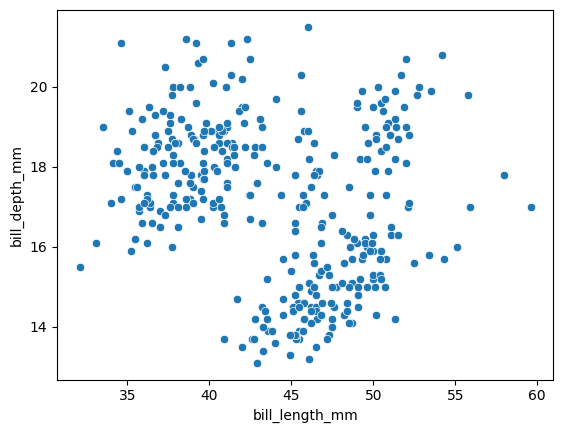

In [ ]:
sns.scatterplot(x="bill_length_mm", y="bill_depth_mm", data=datos);

Con el argumento `hue` podemos indicar el nombre de una varibale que se usa para colorear los puntos:

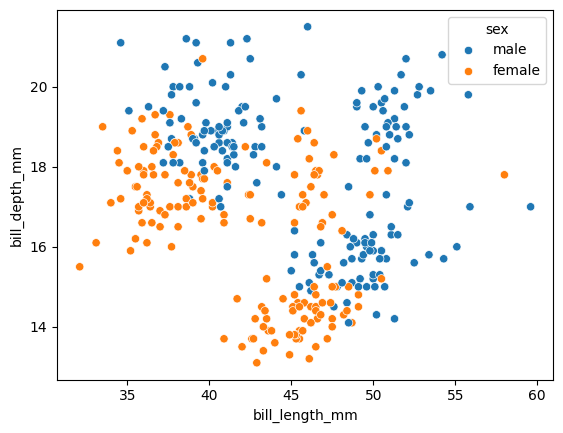

In [ ]:
sns.scatterplot(x="bill_length_mm", y="bill_depth_mm", hue="sex", data=datos);

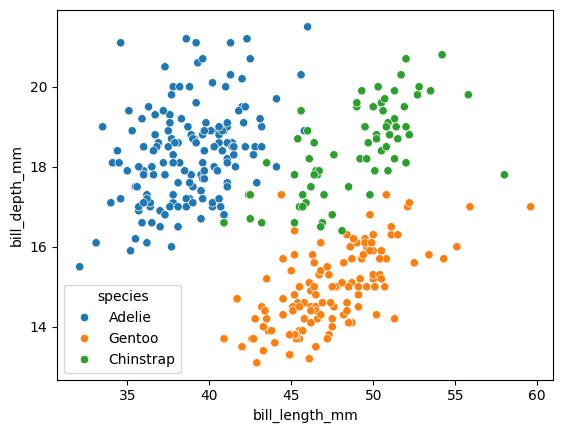

In [ ]:
sns.scatterplot(x="bill_length_mm", y="bill_depth_mm", hue="species", data=datos);

También contamos con la función `.histplot()` que sirve para generar histogramas.

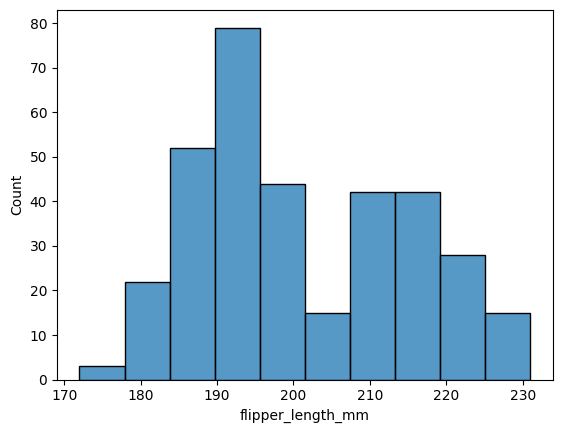

In [ ]:
sns.histplot(x="flipper_length_mm", data=datos);

Esta función también nos permite usar `hue`.

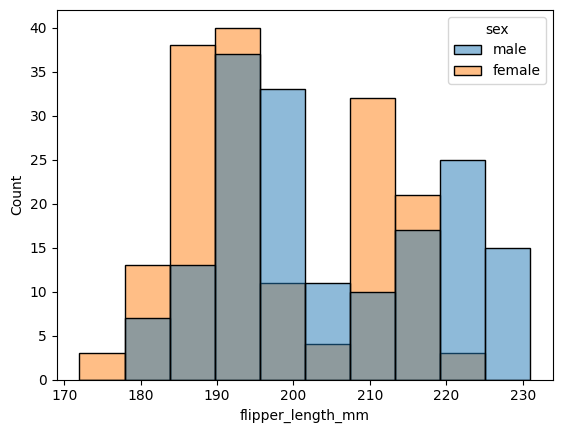

In [ ]:
sns.histplot(x="flipper_length_mm", hue="sex", data=datos);

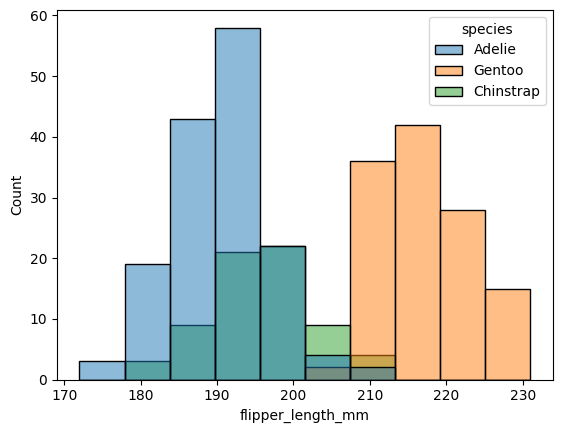

In [ ]:
sns.histplot(x="flipper_length_mm", hue="species", data=datos);

Podemos controlar la cantidad de intervalos en el histograma con el argumento `bins`.

In [ ]:
[
    [10, 20],
    [20, 30],
    [30, 40],
    [40, 60]
]

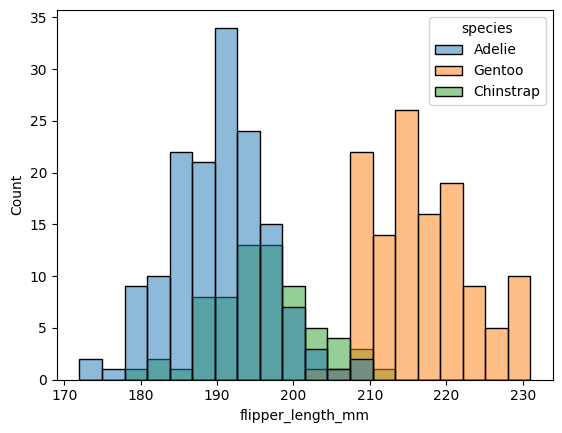

In [ ]:
sns.histplot(x="flipper_length_mm", hue="species", bins=20, data=datos);

Y también podemos modificar como se grafican las alturas de los intervalos.

En este caso, utilizamos una opción que elimina las barras y solo deja las alturas. De esta forma se puede visualizar de mejor manera a cada especie.

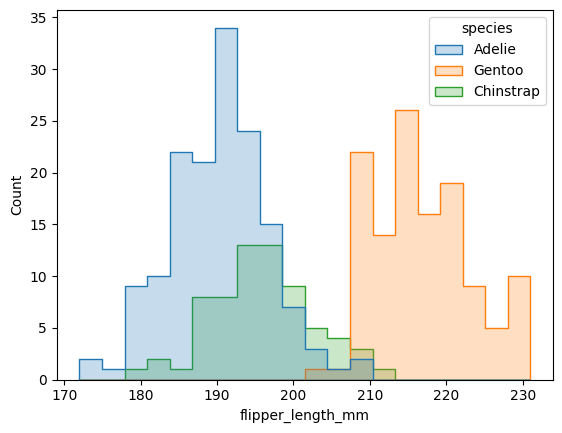

In [ ]:
sns.histplot(x="flipper_length_mm", hue="species", bins=20, element="step", data=datos);

Como su nombre lo indica, la función `.boxplot()` genera boxplots.

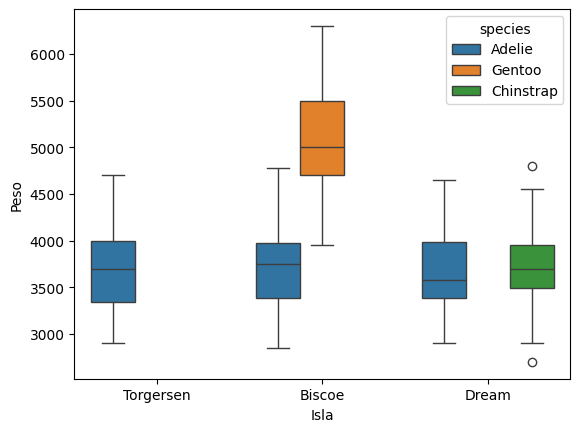

In [ ]:
g = sns.boxplot(x="island", y="body_mass_g", hue="species", data=datos)
g.set_xlabel("Isla")
g.set_ylabel("Peso");

Todas las funciones que utilizamos hasta ahora devuelven un objeto de un tipo determinado. Este objeto nos permite utilizar métodos para continuar modificando algunos aspectos del gráfico.

Por ejemplo, se puede ver que en el bloque de arriba modificamos la etiqueta del eje horizontal (x) y del eje vertical (y)

**Nota**: Es equivalente hacer `g.set(xlabel="Isla", ylabel="Peso")`

**¿Cómo leer un boxplot?**

<center>
<img src="https://drive.google.com/uc?export=view&id=1p5EzdeCNMlRJKr6pQzgCiPwnz1aNh5z7" style="width:500px"></img>
</center>

Otro tipo de visualización frecuentemente utilizada es el gráfico de barra donde se muestra una cantidad. Por ejemplo, la cantidad de observaciones por especie a través de la función `countplot()` de Seaborn:

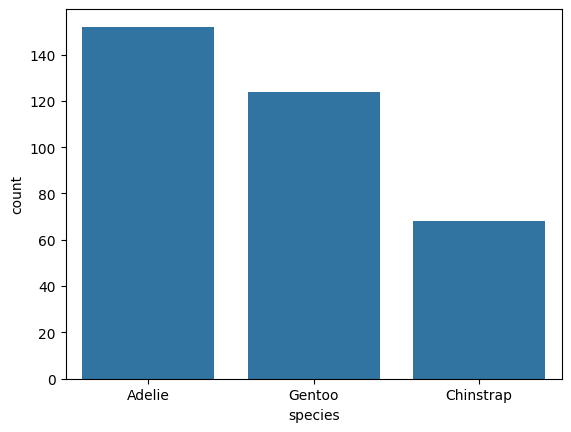

In [ ]:
sns.countplot(x="species", data=datos);

o la cantidad de observaciones por especie e isla:

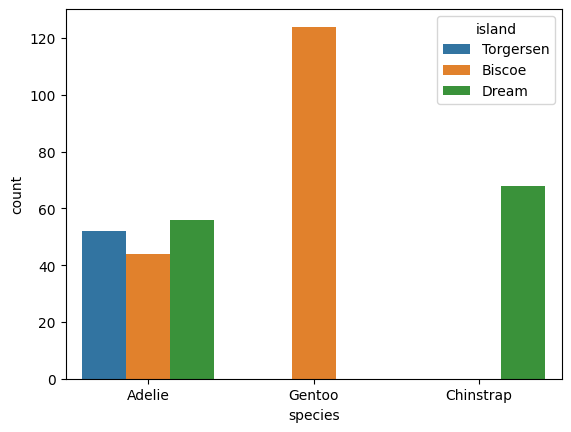

In [ ]:
sns.countplot(x="species", hue="island", data=datos);

En el gráfico anterior se hace evidente que no todas las especies se encontraron en todas las islas.

También es posible hacer que las barras sean horizontales cambiando el nombre del argumento de `x` a `y`.

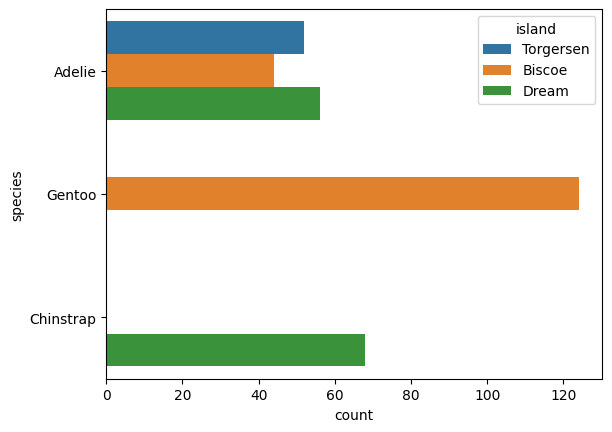

In [ ]:
sns.countplot(y="species", hue="island", data=datos);

Y también es posible utilizar `.barplot`. Pero esta función no cuenta las observaciones por nosotros, sino que tenemos que pasarle el nombre de la variable que contiene la altura de las barras.

Para eso nos construimos un data frame con las categorías (las diferentes islas) y las alturas (la cantidad de pingüinos por isla) y luego lo usamos
en `sns.barplot()`.

In [94]:
df_cantidad_isla = datos.value_counts("island").to_frame("cantidad").reset_index()
df_cantidad_isla

,island,cantidad
0,Biscoe,168
1,Dream,124
2,Torgersen,52


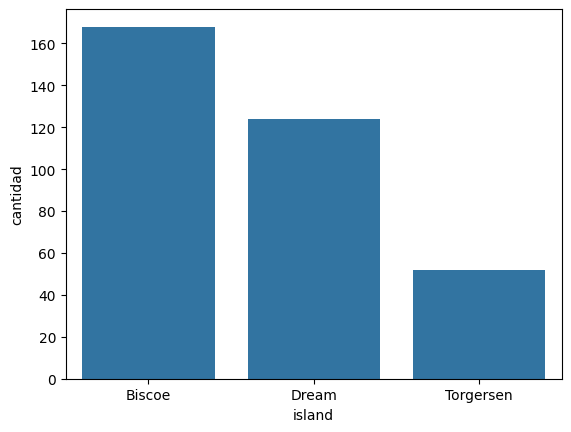

In [ ]:
sns.barplot(x="island", y="cantidad", data=df_cantidad_isla);

Si bien esta función nos hace trabajar más, también significa que tenemos más flexibilidad.

Por ejemplo, en vez de hacer que la altura sea la cantidad de pingüinos, podemos hacer que la altura sea el peso promedio (en este caso, por especie).

In [ ]:
df_pesos_promedios = datos.groupby("species")["body_mass_g"].mean().to_frame("peso promedio").reset_index()
df_pesos_promedios

,species,peso promedio
0,Adelie,3700.662252
1,Chinstrap,3733.088235
2,Gentoo,5076.016260


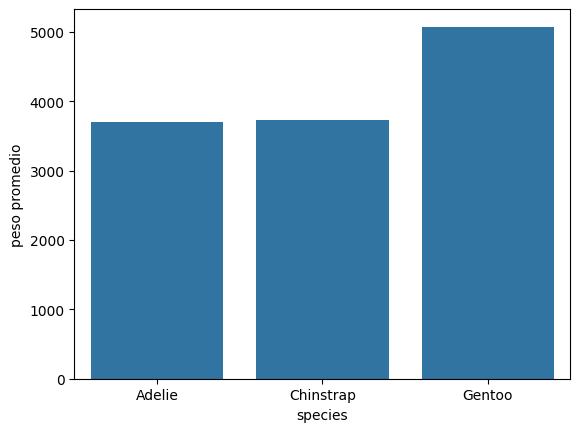

In [ ]:
sns.barplot(x="species", y="peso promedio", data=df_pesos_promedios);

Con este gráfico podemos observar que el peso promedio es similar para Adelie y Chinstrap y que es mayor para la especie Gentoo.

Podemos también utilizar el conjunto de datos originales y por defecto `barplot` va a calcular el promedio de las observaciones. La barra gris que se muestra da idea de un intervalo de confianza.

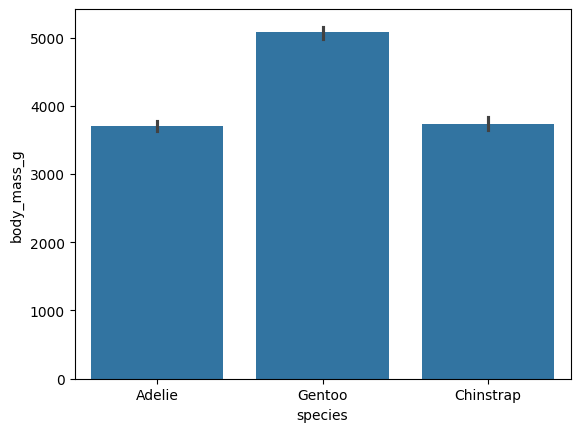

In [ ]:
sns.barplot(x="species", y="body_mass_g", data=datos);

Hay funciones de todos los colores. Por ejemplo, `.lmplot()`. Es una función bastante sofisticada, que genera un gráfico de dispersión y le superpone una recta de regresión.

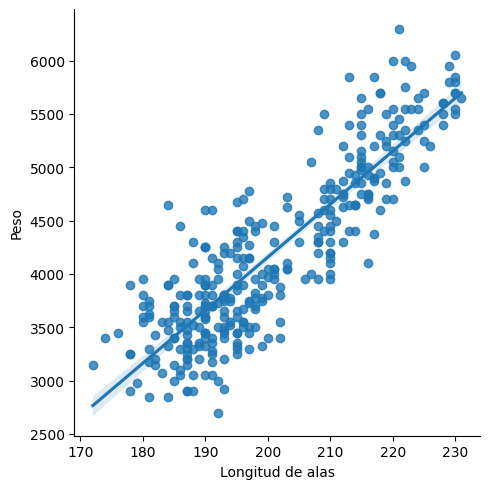

In [ ]:
g = sns.lmplot(x="flipper_length_mm", y="body_mass_g", data=datos)
g.set_xlabels("Longitud de alas")
g.set_ylabels("Peso");

También podemos discriminar por especie y se obtiene una línea para cada especie.

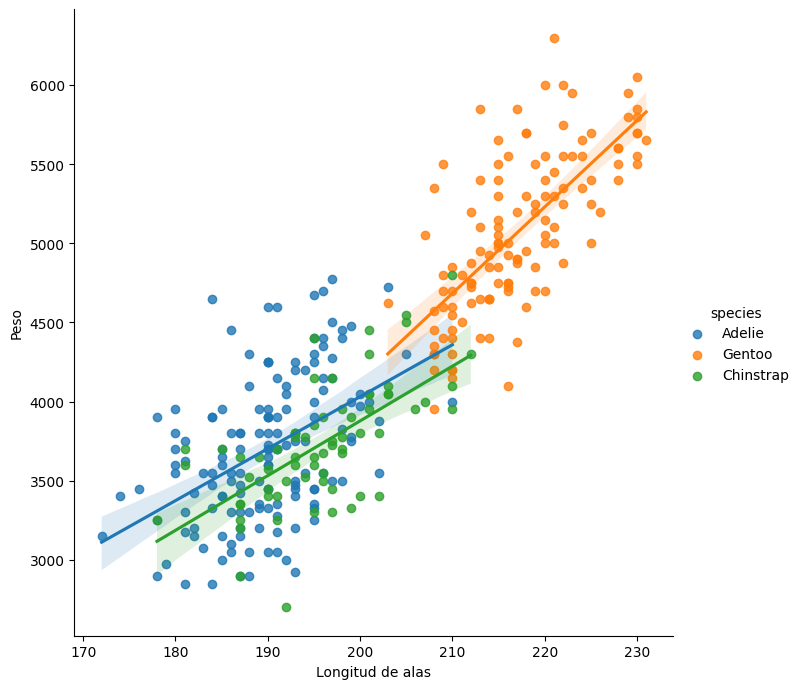

In [ ]:
g = sns.lmplot(
    x="flipper_length_mm", y="body_mass_g", hue="species",
    height=7, data=datos
)
g.set_xlabels("Longitud de alas")
g.set_ylabels("Peso");

La función `.pairplot()` permite visualizar las relaciones entre diferentes variables de nuestro conjunto de datos.

En la diagonal principal, nos muestra un histograma con la distribución de cada variable.

En los otros paneles, nos muestra gráficos de dispersión que permiten observar las relaciones entre las variables.

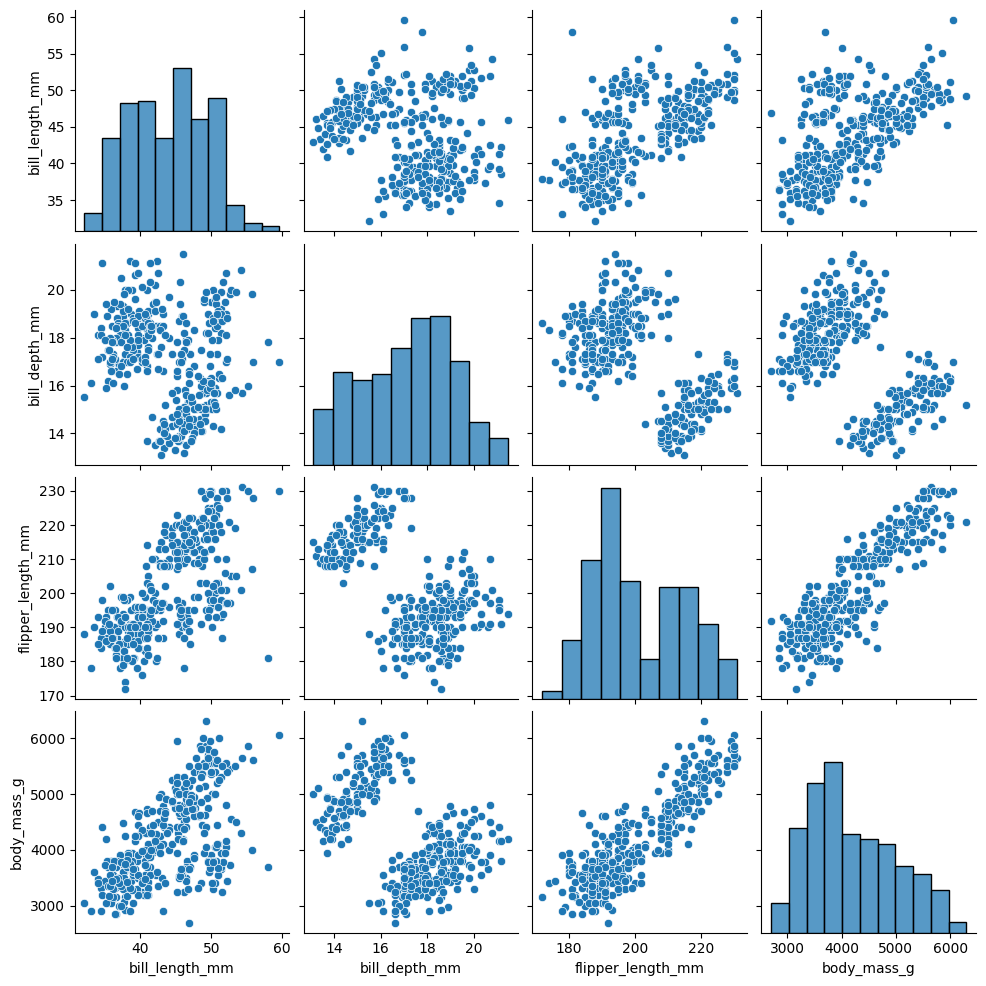

In [ ]:
sns.pairplot(datos[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]]);

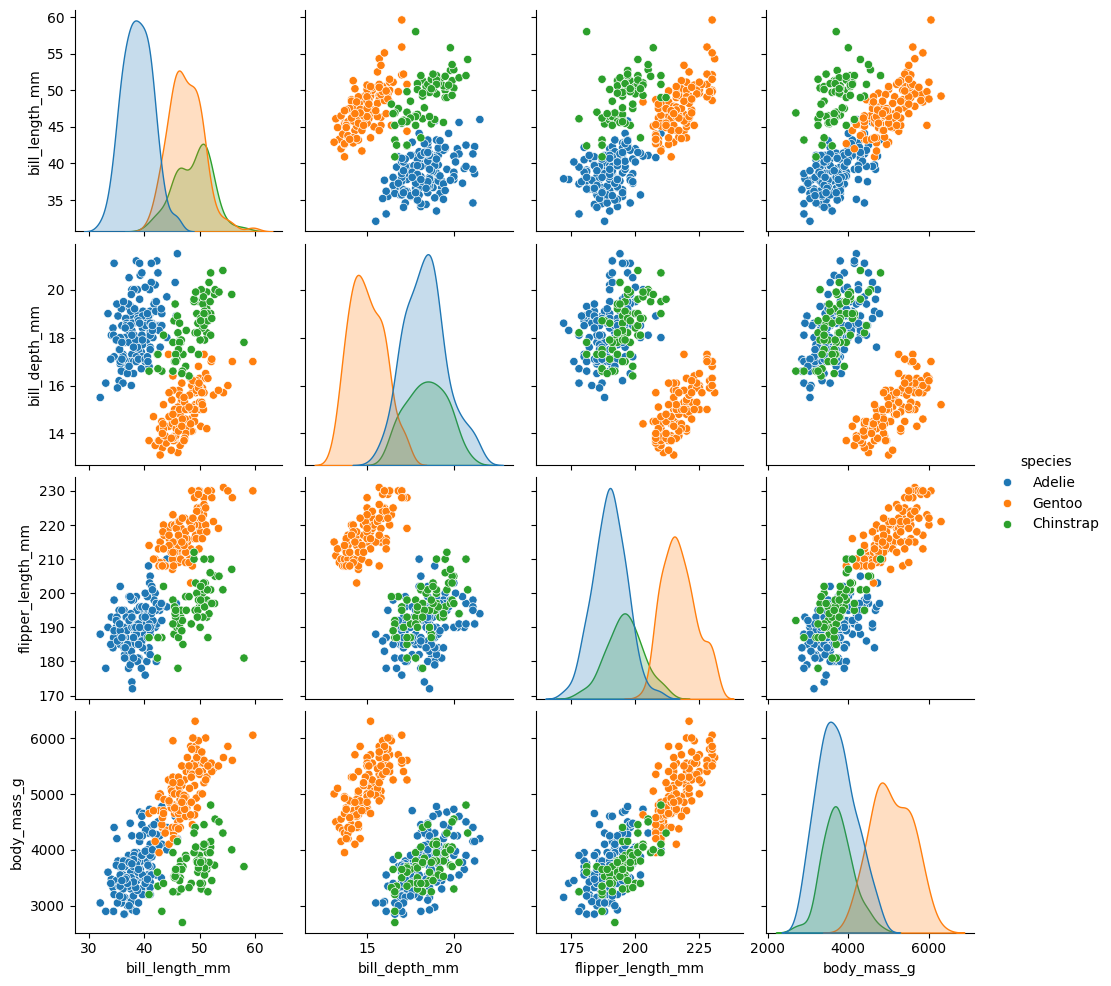

In [ ]:
sns.pairplot(
    datos[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g", "species"]],
    hue="species"
);

En este caso, como utilizamos una tercera dimensión para colorear, `seaborn` utiliza una estimación de densidad en la diagonal.

Si queremos volver a obtener un histograma, utilizamos el argumento `diag_kind`.

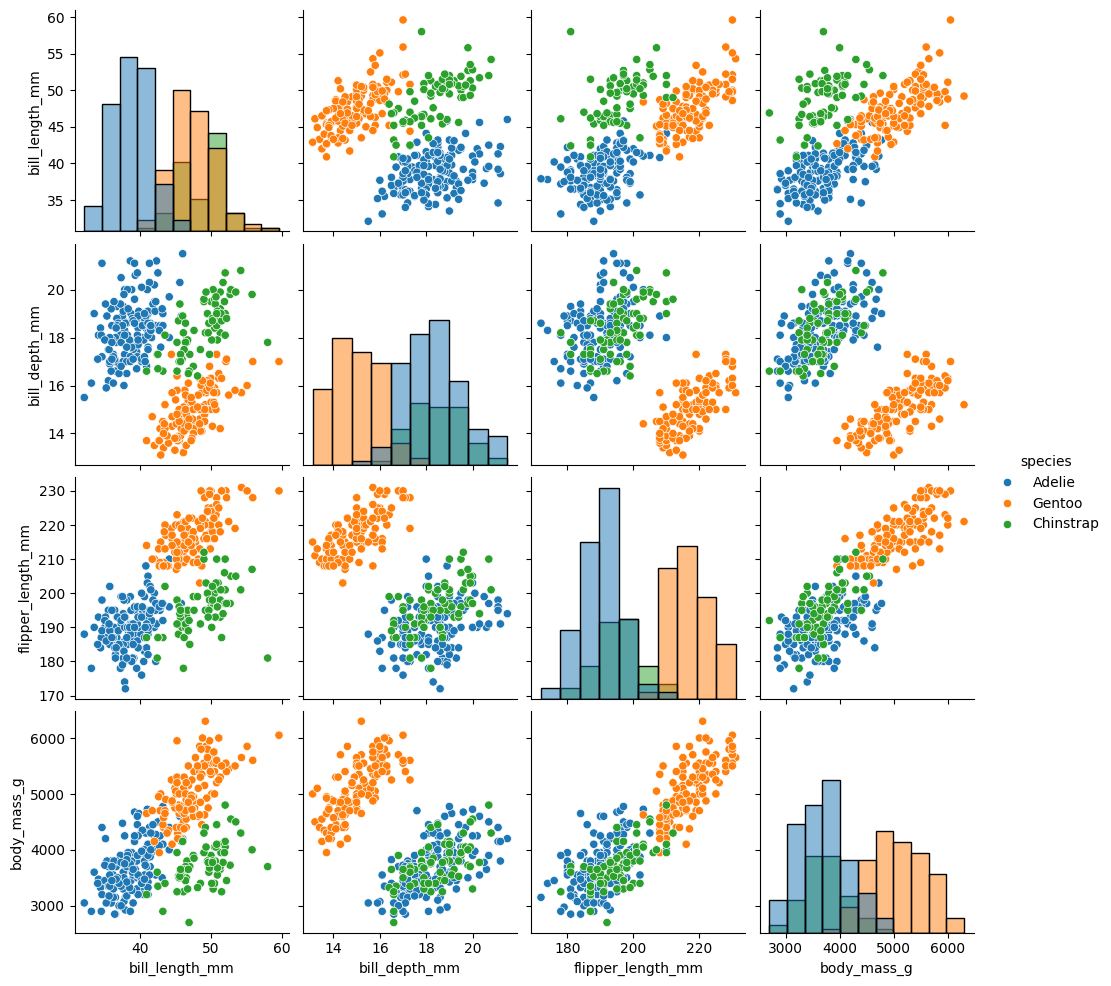

In [ ]:
sns.pairplot(
    datos[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g", "species"]],
    hue="species",
    diag_kind="hist"
);

Finlmente, también podemos seleccionar que variables tomamos para cualquiera de los ejes.

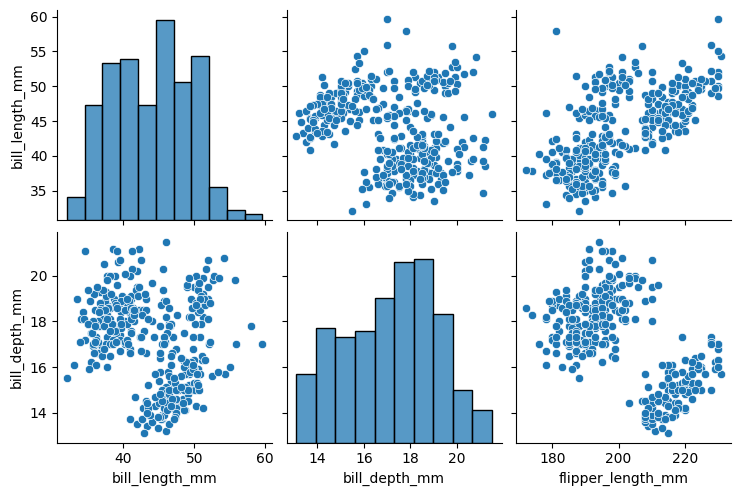

In [ ]:
sns.pairplot(
    datos,
    x_vars=["bill_length_mm", "bill_depth_mm", "flipper_length_mm"],
    y_vars=["bill_length_mm", "bill_depth_mm"],
);

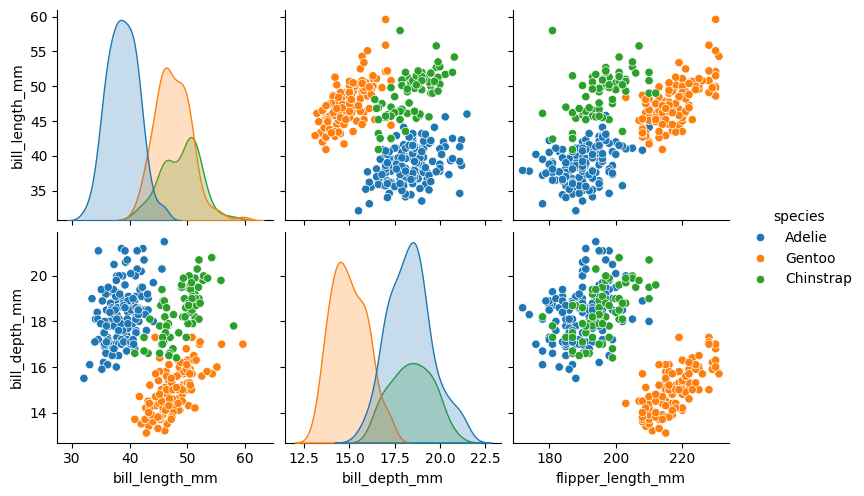

In [ ]:
sns.pairplot(
    datos,
    x_vars=["bill_length_mm", "bill_depth_mm", "flipper_length_mm"],
    y_vars=["bill_length_mm", "bill_depth_mm"],
    hue="species"
);

Finalmente, si nos interesa guardar el gráfico generado podemos utilizar el método `.savefig()`

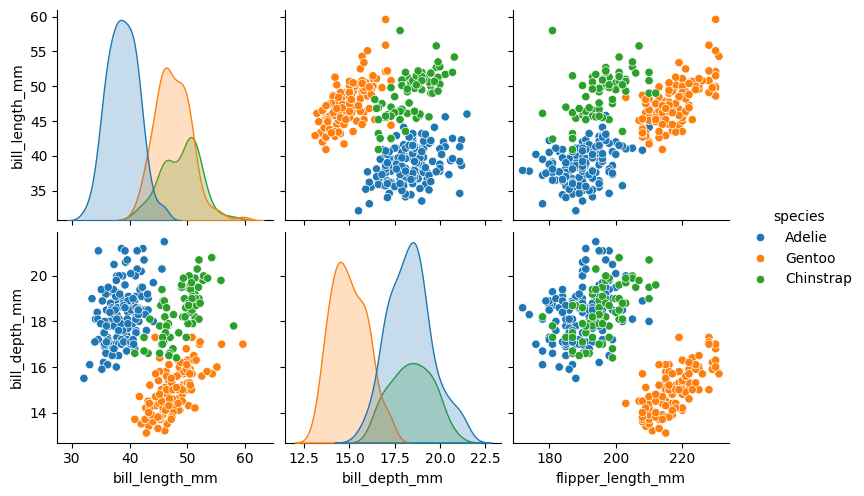

In [ ]:
g = sns.pairplot(
    datos,
    x_vars=["bill_length_mm", "bill_depth_mm", "flipper_length_mm"],
    y_vars=["bill_length_mm", "bill_depth_mm"],
    hue="species"
);

In [ ]:
g.savefig("grafico.png")

Vayamos a observar el gráfico...

**Enlaces útiles**

* [Matplotlib](https://matplotlib.org/).
* [Seaborn](https://seaborn.pydata.org/examples/index.html). Está basada en Matplotlib. Se enfoca en gráficos estadísticos.
* [Python Graph Gallery](https://www.python-graph-gallery.com/): Ejemplos de gráficos hechos en Python.
* [Data Viz PyR](https://datavizpyr.com/category/python/): Más tutoriales de gráficos hechos con Python.